In [1]:
#pip install "numpy<2" --force-reinstall

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('cloud_dataset.csv')

In [4]:
df.head()

,Timestamp,CPU_Usage,Memory_Usage,Disk_IO,Network_IO,Workload_Type,User_ID,Anomaly_Label
0,01-07-2025 00:00,18.88,43.19,11.40,6.01,Database_Query,user_1,0
1,01-07-2025 00:01,25.31,45.43,7.68,17.67,Video_Streaming,user_1,0
2,01-07-2025 00:02,3.87,49.50,14.08,3.48,Database_Query,user_1,0
3,01-07-2025 00:03,20.92,25.88,17.33,4.77,Web_Service,user_1,0
4,01-07-2025 00:04,55.59,43.94,10.61,4.48,Web_Service,user_1,0


In [5]:
df.tail()

,Timestamp,CPU_Usage,Memory_Usage,Disk_IO,Network_IO,Workload_Type,User_ID,Anomaly_Label
14395,01-07-2025 23:55,27.85,51.42,8.98,4.23,Web_Service,user_10,0
14396,01-07-2025 23:56,38.68,43.84,6.04,25.86,Video_Streaming,user_10,0
14397,01-07-2025 23:57,16.50,50.51,8.06,5.83,Database_Query,user_10,0
14398,01-07-2025 23:58,26.31,31.29,9.43,3.99,Database_Query,user_10,0
14399,01-07-2025 23:59,25.94,23.05,12.12,5.57,Web_Service,user_10,0


In [6]:
df.shape

(14400, 8)

In [7]:
print(df.columns.tolist())

['Timestamp', 'CPU_Usage', 'Memory_Usage', 'Disk_IO', 'Network_IO', 'Workload_Type', 'User_ID', 'Anomaly_Label']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14400 entries, 0 to 14399
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Timestamp      14400 non-null  object 
 1   CPU_Usage      14400 non-null  float64
 2   Memory_Usage   14400 non-null  float64
 3   Disk_IO        14400 non-null  float64
 4   Network_IO     14400 non-null  float64
 5   Workload_Type  14400 non-null  object 
 6   User_ID        14400 non-null  object 
 7   Anomaly_Label  14400 non-null  int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 900.1+ KB


In [9]:
df.describe(include='object')

,Timestamp,Workload_Type,User_ID
count,14400,14400,14400
unique,1440,5,10
top,01-07-2025 00:00,Web_Service,user_1
freq,10,4311,1440


In [10]:
df.describe(include='float64')

,CPU_Usage,Memory_Usage,Disk_IO,Network_IO
count,14400.000000,14400.000000,14400.000000,14400.000000
mean,35.558222,44.153315,12.598681,7.993522
std,19.218739,15.300254,9.550537,6.460288
min,-7.130000,3.990000,-9.280000,0.530000
25%,24.157500,34.130000,7.110000,4.510000
50%,31.340000,41.630000,10.680000,5.310000
75%,39.630000,49.702500,14.882500,6.530000
max,100.520000,97.140000,69.700000,42.400000


In [11]:
df.isnull().sum()

Timestamp        0
CPU_Usage        0
Memory_Usage     0
Disk_IO          0
Network_IO       0
Workload_Type    0
User_ID          0
Anomaly_Label    0
dtype: int64

In [12]:
df.Anomaly_Label.value_counts()

Anomaly_Label
0    13143
1     1257
Name: count, dtype: int64

In [13]:
df.groupby("Anomaly_Label").mean(numeric_only=True)

,CPU_Usage,Memory_Usage,Disk_IO,Network_IO
Anomaly_Label,,,,
0,30.705891,44.551875,12.859566,8.275428
1,86.293453,39.986030,9.870907,5.045951


In [14]:
normal = df[df['Anomaly_Label']==0]
normal.describe()

,CPU_Usage,Memory_Usage,Disk_IO,Network_IO,Anomaly_Label
count,13143.000000,13143.000000,13143.000000,13143.000000,13143.0
mean,30.705891,44.551875,12.859566,8.275428,0.0
std,11.554597,15.657728,9.830382,6.687708,0.0
min,-7.130000,3.990000,-9.280000,0.530000,0.0
25%,23.450000,34.215000,7.170000,4.520000,0.0
50%,30.140000,41.820000,10.770000,5.350000,0.0
75%,37.095000,50.035000,15.070000,6.740000,0.0
max,80.000000,97.140000,69.700000,42.400000,0.0


In [15]:
df.Workload_Type.value_counts()

Workload_Type
Web_Service        4311
Database_Query     4296
Video_Streaming    2870
Crypto_Mining      1466
Backup             1457
Name: count, dtype: int64

In [16]:
df.User_ID.value_counts()

User_ID
user_1     1440
user_2     1440
user_3     1440
user_4     1440
user_5     1440
user_6     1440
user_7     1440
user_8     1440
user_9     1440
user_10    1440
Name: count, dtype: int64

In [17]:
anomaly = df[df['Anomaly_Label']==1]
anomaly.describe()

,CPU_Usage,Memory_Usage,Disk_IO,Network_IO,Anomaly_Label
count,1257.000000,1257.000000,1257.000000,1257.000000,1257.0
mean,86.293453,39.986030,9.870907,5.045951,1.0
std,3.867925,9.972315,5.135843,0.977271,0.0
min,80.000000,7.780000,-8.180000,1.930000,1.0
25%,83.220000,33.470000,6.440000,4.410000,1.0
50%,85.940000,39.880000,9.940000,5.070000,1.0
75%,88.690000,46.600000,13.170000,5.720000,1.0
max,100.520000,72.160000,26.730000,7.960000,1.0


In [18]:
df.Timestamp = pd.to_datetime(df['Timestamp'])

In [19]:
df['Timestamp'].dtype

dtype('<M8[ns]')

In [20]:
df = df.sort_values("Timestamp")

df["Timestamp"].min()
df["Timestamp"].max()

Timestamp('2025-01-07 23:59:00')

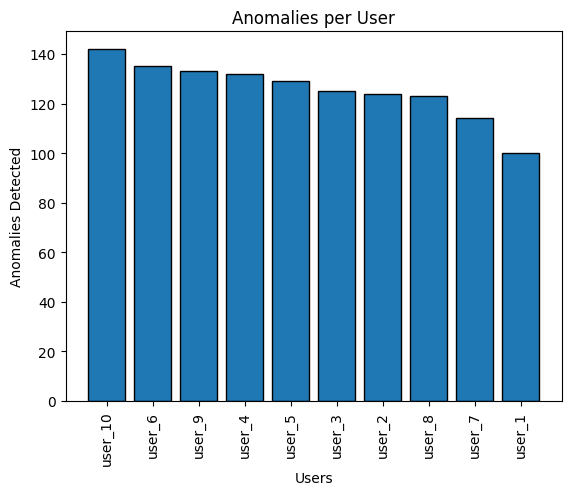

In [21]:
import matplotlib.pyplot as plt
anomaly_counts = df[df['Anomaly_Label'] == 1]['User_ID'].value_counts()
plt.bar(anomaly_counts.index, anomaly_counts.values,edgecolor='black')
plt.xlabel('Users')
plt.ylabel('Anomalies Detected')
plt.title('Anomalies per User')
plt.xticks(rotation=90)  # rotate labels if too many users
plt.show()


<Axes: >

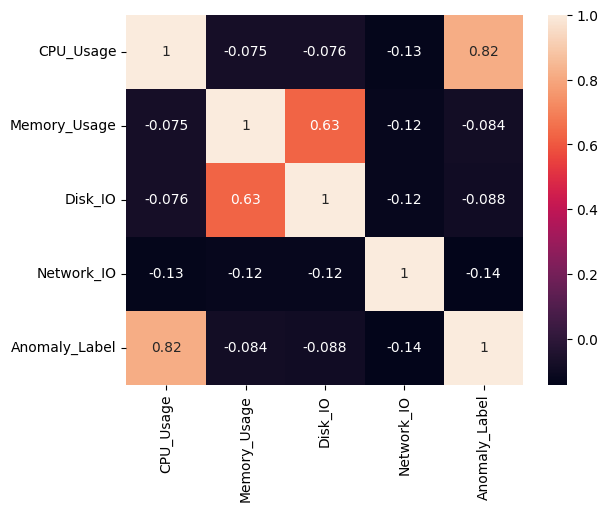

In [22]:
import seaborn as sns 
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

(array([20095.   , 20095.125, 20095.25 , 20095.375, 20095.5  , 20095.625,
        20095.75 , 20095.875, 20096.   ]),
 [Text(20095.0, 0, '01-07 00'),
  Text(20095.125, 0, '01-07 03'),
  Text(20095.25, 0, '01-07 06'),
  Text(20095.375, 0, '01-07 09'),
  Text(20095.5, 0, '01-07 12'),
  Text(20095.625, 0, '01-07 15'),
  Text(20095.75, 0, '01-07 18'),
  Text(20095.875, 0, '01-07 21'),
  Text(20096.0, 0, '01-08 00')])

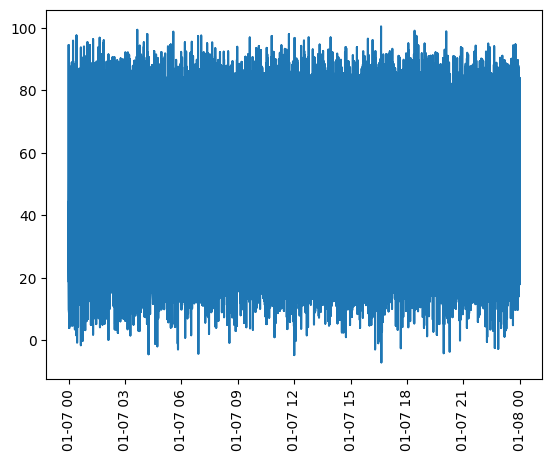

In [23]:
plt.plot(df.Timestamp,df.CPU_Usage)
plt.xticks(rotation =90)

(array([20095.   , 20095.125, 20095.25 , 20095.375, 20095.5  , 20095.625,
        20095.75 , 20095.875, 20096.   ]),
 [Text(20095.0, 0, '01-07 00'),
  Text(20095.125, 0, '01-07 03'),
  Text(20095.25, 0, '01-07 06'),
  Text(20095.375, 0, '01-07 09'),
  Text(20095.5, 0, '01-07 12'),
  Text(20095.625, 0, '01-07 15'),
  Text(20095.75, 0, '01-07 18'),
  Text(20095.875, 0, '01-07 21'),
  Text(20096.0, 0, '01-08 00')])

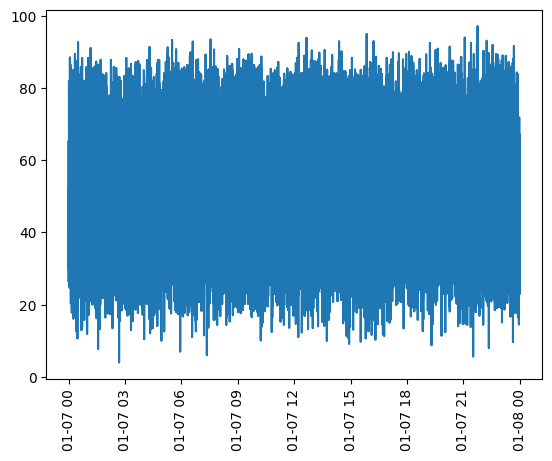

In [24]:
plt.plot(df.Timestamp,df.Memory_Usage)
plt.xticks(rotation =90)

(array([20095.   , 20095.125, 20095.25 , 20095.375, 20095.5  , 20095.625,
        20095.75 , 20095.875, 20096.   ]),
 [Text(20095.0, 0, '01-07 00'),
  Text(20095.125, 0, '01-07 03'),
  Text(20095.25, 0, '01-07 06'),
  Text(20095.375, 0, '01-07 09'),
  Text(20095.5, 0, '01-07 12'),
  Text(20095.625, 0, '01-07 15'),
  Text(20095.75, 0, '01-07 18'),
  Text(20095.875, 0, '01-07 21'),
  Text(20096.0, 0, '01-08 00')])

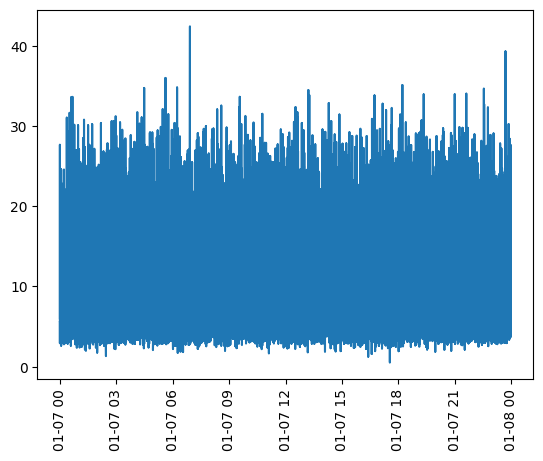

In [25]:
plt.plot(df.Timestamp,df.Network_IO)
plt.xticks(rotation =90)

(array([20095.   , 20095.125, 20095.25 , 20095.375, 20095.5  , 20095.625,
        20095.75 , 20095.875, 20096.   ]),
 [Text(20095.0, 0, '01-07 00'),
  Text(20095.125, 0, '01-07 03'),
  Text(20095.25, 0, '01-07 06'),
  Text(20095.375, 0, '01-07 09'),
  Text(20095.5, 0, '01-07 12'),
  Text(20095.625, 0, '01-07 15'),
  Text(20095.75, 0, '01-07 18'),
  Text(20095.875, 0, '01-07 21'),
  Text(20096.0, 0, '01-08 00')])

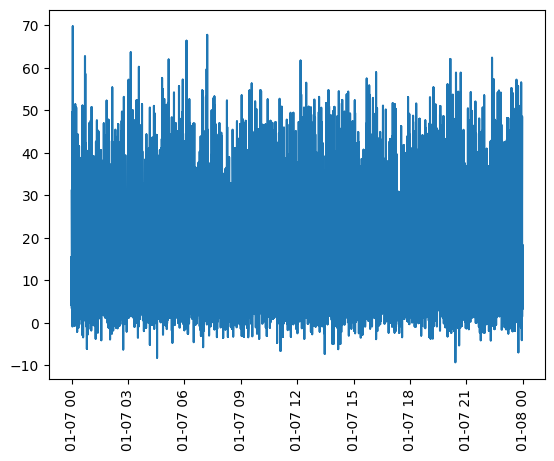

In [26]:
plt.plot(df.Timestamp,df.Disk_IO)
plt.xticks(rotation =90)